In [ ]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importation des fichiers
sirh = pd.read_csv("extrait_sirh.csv")
eval_perf = pd.read_csv("extrait_eval.csv")
sondage = pd.read_csv("extrait_sondage.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


ModuleNotFoundError: No module named 'sklearn'

In [2]:
sirh.head(3)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0


In [3]:
eval_perf.head(3)


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %


In [4]:
sondage.head(3)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0


In [5]:
# Nombre de lignes et de colonnes du fichier SIRH
sirh.shape

(1470, 12)

In [6]:
sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


In [7]:
# Identifier les colonnes correspondantes à des infos quantitatives
sirh_colonnes_quantitatives=sirh.select_dtypes(include=["int64"])
# Identifier les colonnes correspondantes à des infos qualitatives
sirh_colonnes_qualitatives=sirh.select_dtypes(include=["object"])
# Exclure l'identifiant des colonnes quantitatives
sirh_colonnes_quantitatives=sirh_colonnes_quantitatives.drop(columns=["id_employee"])
print(sirh_colonnes_quantitatives)


      age  revenu_mensuel  nombre_experiences_precedentes  \
0      41            5993                               8   
1      49            5130                               1   
2      37            2090                               6   
3      33            2909                               1   
4      27            3468                               9   
...   ...             ...                             ...   
1465   36            2571                               4   
1466   39            9991                               4   
1467   27            6142                               1   
1468   49            5390                               2   
1469   34            4404                               2   

      nombre_heures_travailless  annee_experience_totale  \
0                            80                        8   
1                            80                       10   
2                            80                        7   
3                          

In [8]:
sirh.nunique()


id_employee                       1470
age                                 43
genre                                2
revenu_mensuel                    1349
statut_marital                       3
departement                          3
poste                                9
nombre_experiences_precedentes      10
nombre_heures_travailless            1
annee_experience_totale             40
annees_dans_l_entreprise            37
annees_dans_le_poste_actuel         19
dtype: int64

In [9]:
# valeurs uniques pour toutes les colonnes du dataframe
for col in sirh.columns:
    print(f"Valeurs uniques pour {col}:")
    print(sirh[col].unique())
    print() 

Valeurs uniques pour id_employee:
[   1    2    4 ... 2064 2065 2068]

Valeurs uniques pour age:
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]

Valeurs uniques pour genre:
['F' 'M']

Valeurs uniques pour revenu_mensuel:
[5993 5130 2090 ... 9991 5390 4404]

Valeurs uniques pour statut_marital:
['Célibataire' 'Marié(e)' 'Divorcé(e)']

Valeurs uniques pour departement:
['Commercial' 'Consulting' 'Ressources Humaines']

Valeurs uniques pour poste:
['Cadre Commercial' 'Assistant de Direction' 'Consultant' 'Tech Lead'
 'Manager' 'Senior Manager' 'Représentant Commercial'
 'Directeur Technique' 'Ressources Humaines']

Valeurs uniques pour nombre_experiences_precedentes:
[8 1 6 9 0 4 5 2 7 3]

Valeurs uniques pour nombre_heures_travailless:
[80]

Valeurs uniques pour annee_experience_totale:
[ 8 10  7  6 12  1 17  5  3 31 13  0 26 24 22  9 19  2 23 14 15  4 29 28
 21 25 20 11 16 37 38 30 40 18 36 34 32 33 35 

In [10]:
# Vérifier si l'age n'est pas inférieur aux années d'expérience
sirh[sirh["annee_experience_totale"]>sirh["age"]]


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel


In [11]:
print(sirh['id_employee'].is_unique)
# vérifie si des valeurs sont manquantes dans le dataframe
sirh.isna().sum()

True


id_employee                       0
age                               0
genre                             0
revenu_mensuel                    0
statut_marital                    0
departement                       0
poste                             0
nombre_experiences_precedentes    0
nombre_heures_travailless         0
annee_experience_totale           0
annees_dans_l_entreprise          0
annees_dans_le_poste_actuel       0
dtype: int64

In [12]:
# Nettoyer les colonnes qualitatives en mettant en minuscule le texte et supprimer les espaces

# récupération des colonnes qualitatives
colonnes_qualitatives=sirh.select_dtypes(include=["object"]).columns
# Nettoyage des colonnes
sirh[colonnes_qualitatives]=sirh[colonnes_qualitatives].apply(lambda col: col.str.strip().str.lower())
print(sirh.head(2))


   id_employee  age genre  revenu_mensuel statut_marital departement  \
0            1   41     f            5993    célibataire  commercial   
1            2   49     m            5130       marié(e)  consulting   

                    poste  nombre_experiences_precedentes  \
0        cadre commercial                               8   
1  assistant de direction                               1   

   nombre_heures_travailless  annee_experience_totale  \
0                         80                        8   
1                         80                       10   

   annees_dans_l_entreprise  annees_dans_le_poste_actuel  
0                         6                            4  
1                        10                            7  


In [13]:
sirh.describe(include="all")

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
count,1470.000000,1470.000000,1470,1470.000000,1470,1470,1470,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
unique,NaN,NaN,2,NaN,3,3,9,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,m,NaN,marié(e),consulting,cadre commercial,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,882,NaN,673,961,326,NaN,NaN,NaN,NaN,NaN
mean,1024.865306,36.923810,NaN,6502.931293,NaN,NaN,NaN,2.693197,80.0,11.279592,7.008163,4.229252
std,602.024335,9.135373,NaN,4707.956783,NaN,NaN,NaN,2.498009,0.0,7.780782,6.126525,3.623137
min,1.000000,18.000000,NaN,1009.000000,NaN,NaN,NaN,0.000000,80.0,0.000000,0.000000,0.000000
25%,491.250000,30.000000,NaN,2911.000000,NaN,NaN,NaN,1.000000,80.0,6.000000,3.000000,2.000000
50%,1020.500000,36.000000,NaN,4919.000000,NaN,NaN,NaN,2.000000,80.0,10.000000,5.000000,3.000000
75%,1555.750000,43.000000,NaN,8379.000000,NaN,NaN,NaN,4.000000,80.0,15.000000,9.000000,7.000000


In [14]:
# Vérifier si d'autres employés ont des salaraires au dessus de 10000 par mois
sirh.loc[sirh["revenu_mensuel"]>=10000]

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
18,23,53,f,15427,marié(e),commercial,senior manager,2,80,31,25,8
22,28,34,f,11994,célibataire,consulting,directeur technique,0,80,13,12,6
25,32,53,f,19094,divorcé(e),consulting,senior manager,4,80,26,14,13
28,36,44,f,10248,marié(e),consulting,manager,3,80,24,22,6
29,38,46,f,18947,célibataire,commercial,senior manager,3,80,22,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1437,2022,39,m,19431,célibataire,consulting,senior manager,2,80,21,6,0
1443,2031,42,m,18880,marié(e),consulting,senior manager,5,80,24,22,6
1445,2034,41,f,13570,marié(e),consulting,tech lead,0,80,21,20,7
1461,2055,50,m,10854,divorcé(e),commercial,cadre commercial,4,80,20,3,2


In [15]:
# Nombre de lignes et de colonnes du fichier EVALUATION
eval_perf.shape

(1470, 10)

In [16]:
eval_perf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
dtypes: int64(7), object(3)
memory usage:

In [17]:
eval_perf.nunique()

satisfaction_employee_environnement             4
note_evaluation_precedente                      4
niveau_hierarchique_poste                       5
satisfaction_employee_nature_travail            4
satisfaction_employee_equipe                    4
satisfaction_employee_equilibre_pro_perso       4
eval_number                                  1470
note_evaluation_actuelle                        2
heure_supplementaires                           2
augementation_salaire_precedente               15
dtype: int64

In [18]:
# Identifier les colonnes correspondantes à des infos quantitatives
eval_perf_colonnes_quantitatives=eval_perf.select_dtypes(include=["int64"])
# Identifier les colonnes correspondantes à des infos qualitatives
eval_perf_colonnes_qualitatives=eval_perf.select_dtypes(include=["object"])

print(eval_perf_colonnes_quantitatives.head(2))
print(eval_perf_colonnes_qualitatives.head(2))

   satisfaction_employee_environnement  note_evaluation_precedente  \
0                                    2                           3   
1                                    3                           2   

   niveau_hierarchique_poste  satisfaction_employee_nature_travail  \
0                          2                                     4   
1                          2                                     2   

   satisfaction_employee_equipe  satisfaction_employee_equilibre_pro_perso  \
0                             1                                          1   
1                             4                                          3   

   note_evaluation_actuelle  
0                         3  
1                         4  
  eval_number heure_supplementaires augementation_salaire_precedente
0         E_1                   Oui                             11 %
1         E_2                   Non                             23 %


In [19]:
# valeurs uniques pour toutes les colonnes du dataframe
for col in eval_perf.columns:
    print(f"Valeurs uniques pour {col}:")
    print(eval_perf[col].unique())
    print() 

Valeurs uniques pour satisfaction_employee_environnement:
[2 3 4 1]

Valeurs uniques pour note_evaluation_precedente:
[3 2 4 1]

Valeurs uniques pour niveau_hierarchique_poste:
[2 1 3 4 5]

Valeurs uniques pour satisfaction_employee_nature_travail:
[4 2 3 1]

Valeurs uniques pour satisfaction_employee_equipe:
[1 4 2 3]

Valeurs uniques pour satisfaction_employee_equilibre_pro_perso:
[1 3 2 4]

Valeurs uniques pour eval_number:
['E_1' 'E_2' 'E_4' ... 'E_2064' 'E_2065' 'E_2068']

Valeurs uniques pour note_evaluation_actuelle:
[3 4]

Valeurs uniques pour heure_supplementaires:
['Oui' 'Non']

Valeurs uniques pour augementation_salaire_precedente:
['11 %' '23 %' '15 %' '12 %' '13 %' '20 %' '22 %' '21 %' '17 %' '14 %'
 '16 %' '18 %' '19 %' '24 %' '25 %']



In [20]:
print(eval_perf['eval_number'].is_unique)
# vérifie si des valeurs sont manquantes dans le dataframe
eval_perf.isna().sum()

True


satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
eval_number                                  0
note_evaluation_actuelle                     0
heure_supplementaires                        0
augementation_salaire_precedente             0
dtype: int64

In [21]:
# Retrait des pourcentages de la colonne augementation_salaire_précédent et changement de type en float au lieu du string initial
eval_perf["augementation_salaire_precedente"]=(eval_perf["augementation_salaire_precedente"].str.replace("%","").str.strip().astype(float)/100)

In [22]:
# Vérification
eval_perf["augementation_salaire_precedente"].apply(type).value_counts()
print(eval_perf["augementation_salaire_precedente"].head())

0    0.11
1    0.23
2    0.15
3    0.11
4    0.12
Name: augementation_salaire_precedente, dtype: float64


In [23]:
# Nettoyer les colonnes qualitatives en mettant en minuscule le texte et supprimer les espaces

# récupération des colonnes qualitatives
colonnes_qualitatives=eval_perf.select_dtypes(include=["object"]).columns
# Nettoyage des colonnes
eval_perf[colonnes_qualitatives]=eval_perf[colonnes_qualitatives].apply(lambda col: col.str.strip().str.lower())
print(eval_perf.head(2))

   satisfaction_employee_environnement  note_evaluation_precedente  \
0                                    2                           3   
1                                    3                           2   

   niveau_hierarchique_poste  satisfaction_employee_nature_travail  \
0                          2                                     4   
1                          2                                     2   

   satisfaction_employee_equipe  satisfaction_employee_equilibre_pro_perso  \
0                             1                                          1   
1                             4                                          3   

  eval_number  note_evaluation_actuelle heure_supplementaires  \
0         e_1                         3                   oui   
1         e_2                         4                   non   

   augementation_salaire_precedente  
0                              0.11  
1                              0.23  


In [24]:
eval_perf.describe(include="all")

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,1470,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,e_1,NaN,non,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1054,NaN
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,NaN,3.153741,NaN,0.152095
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,NaN,0.360824,NaN,0.036599
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,3.000000,NaN,0.110000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,NaN,3.000000,NaN,0.120000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,NaN,3.000000,NaN,0.140000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,NaN,3.000000,NaN,0.180000


In [25]:
# Nombre de lignes et de colonnes du fichier SONDAGE
sondage.shape

(1470, 12)

In [26]:
sondage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [27]:
# Identifier les colonnes correspondantes à des infos quantitatives
sondage_colonnes_quantitatives=sondage.select_dtypes(include=["int64"])
# Identifier les colonnes correspondantes à des infos qualitatives
sondage_colonnes_qualitatives=sondage.select_dtypes(include=["object"])

print(sondage_colonnes_quantitatives.head(2))
print(sondage_colonnes_qualitatives.head(2))

   nombre_participation_pee  nb_formations_suivies  \
0                         0                      0   
1                         1                      3   

   nombre_employee_sous_responsabilite  code_sondage  \
0                                    1             1   
1                                    1             2   

   distance_domicile_travail  niveau_education  \
0                          1                 2   
1                          8                 1   

   annees_depuis_la_derniere_promotion  annes_sous_responsable_actuel  
0                                    0                              5  
1                                    1                              7  
  a_quitte_l_entreprise  domaine_etude ayant_enfants frequence_deplacement
0                   Oui  Infra & Cloud             Y           Occasionnel
1                   Non  Infra & Cloud             Y              Frequent


In [28]:
# Nettoyer les colonnes qualitatives en mettant en minuscule le texte et supprimer les espaces

# récupération des colonnes qualitatives
sondage_colonnes_qualitatives=sondage.select_dtypes(include=["object"]).columns
# Nettoyage des colonnes
sondage[sondage_colonnes_qualitatives]=sondage[sondage_colonnes_qualitatives].apply(lambda col: col.str.strip().str.lower())
print(sondage.head(2))

  a_quitte_l_entreprise  nombre_participation_pee  nb_formations_suivies  \
0                   oui                         0                      0   
1                   non                         1                      3   

   nombre_employee_sous_responsabilite  code_sondage  \
0                                    1             1   
1                                    1             2   

   distance_domicile_travail  niveau_education  domaine_etude ayant_enfants  \
0                          1                 2  infra & cloud             y   
1                          8                 1  infra & cloud             y   

  frequence_deplacement  annees_depuis_la_derniere_promotion  \
0           occasionnel                                    0   
1              frequent                                    1   

   annes_sous_responsable_actuel  
0                              5  
1                              7  


In [29]:
sondage.nunique()

a_quitte_l_entreprise                     2
nombre_participation_pee                  4
nb_formations_suivies                     7
nombre_employee_sous_responsabilite       1
code_sondage                           1470
distance_domicile_travail                29
niveau_education                          5
domaine_etude                             6
ayant_enfants                             1
frequence_deplacement                     3
annees_depuis_la_derniere_promotion      16
annes_sous_responsable_actuel            18
dtype: int64

In [30]:
# valeurs uniques pour toutes les colonnes du dataframe
for col in sondage.columns:
    print(f"Valeurs uniques pour {col}:")
    print(sondage[col].unique())
    print() 

Valeurs uniques pour a_quitte_l_entreprise:
['oui' 'non']

Valeurs uniques pour nombre_participation_pee:
[0 1 3 2]

Valeurs uniques pour nb_formations_suivies:
[0 3 2 5 1 4 6]

Valeurs uniques pour nombre_employee_sous_responsabilite:
[1]

Valeurs uniques pour code_sondage:
[   1    2    4 ... 2064 2065 2068]

Valeurs uniques pour distance_domicile_travail:
[ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25 12 18 29 22
 14 20 28 17 13]

Valeurs uniques pour niveau_education:
[2 1 4 3 5]

Valeurs uniques pour domaine_etude:
['infra & cloud' 'autre' 'transformation digitale' 'marketing'
 'entrepreunariat' 'ressources humaines']

Valeurs uniques pour ayant_enfants:
['y']

Valeurs uniques pour frequence_deplacement:
['occasionnel' 'frequent' 'aucun']

Valeurs uniques pour annees_depuis_la_derniere_promotion:
[ 0  1  3  2  7  4  8  6  5 15  9 13 12 10 11 14]

Valeurs uniques pour annes_sous_responsable_actuel:
[ 5  7  0  2  6  8  3 11 17  1  4 12  9 10 15 13 16 14]



In [31]:
print(sondage["code_sondage"].value_counts())

code_sondage
1       1
2       1
4       1
5       1
7       1
       ..
2061    1
2062    1
2064    1
2065    1
2068    1
Name: count, Length: 1470, dtype: int64


In [32]:
print(sondage['code_sondage'].is_unique)

True


In [33]:
sondage.isna().sum()

a_quitte_l_entreprise                  0
nombre_participation_pee               0
nb_formations_suivies                  0
nombre_employee_sous_responsabilite    0
code_sondage                           0
distance_domicile_travail              0
niveau_education                       0
domaine_etude                          0
ayant_enfants                          0
frequence_deplacement                  0
annees_depuis_la_derniere_promotion    0
annes_sous_responsable_actuel          0
dtype: int64

In [34]:
# FUSION DES FICHIERS

# Renommer les colonnes des identifiants 
sondage=sondage.rename(columns={"code_sondage":"id"})
eval_perf=eval_perf.rename(columns={"eval_number":"id"})
sirh=sirh.rename(columns={"id_employee":"id"})

# Retirer les lettres de la colonne id du fichier eval_perf
eval_perf["id"]=eval_perf["id"].str.extract(r"(\d+)")

# Passer la colonne en integer
eval_perf["id"]=eval_perf["id"].astype(int)
print(eval_perf["id"])

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: id, Length: 1470, dtype: int64


In [40]:
# fusion des trois fichiers
df_merge_1=sirh.merge(eval_perf, on="id", how="inner")
df_merge=df_merge_1.merge(sondage, on="id", how="inner")
df_merge.info()
df_merge.to_csv("df_merge.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

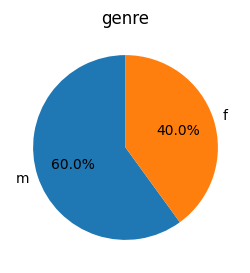

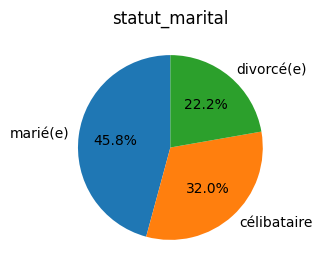

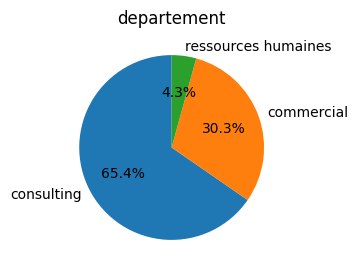

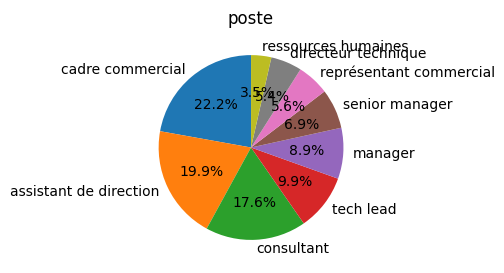

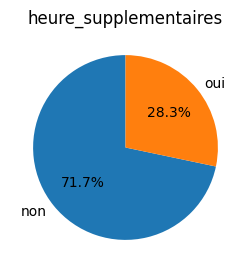

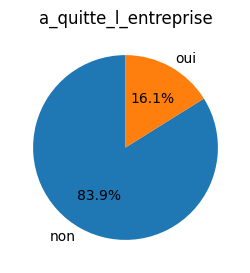

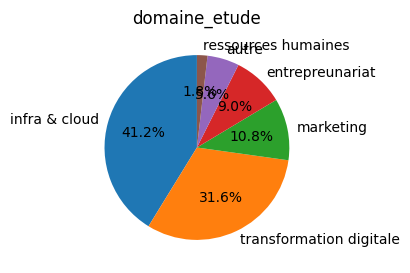

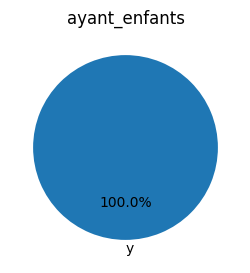

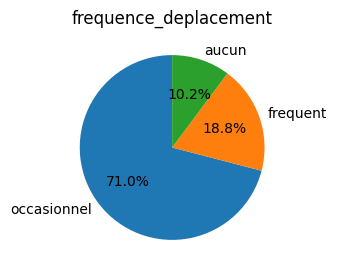

In [36]:
# Sélection des colonnes qualitatives
df_colonnes_qualitatives = df_merge.select_dtypes(include=["object"]).columns

# Boucle sur chaque colonne qualitative
for var in df_colonnes_qualitatives:
    # Comptage des valeurs
    counts = df_merge[var].value_counts()

    # Création du camembert
    plt.figure(figsize=(3,3))  # taille du graphique
    counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)  # startangle pour tourner le camembert
    plt.title(var)
    plt.ylabel("")  # enlève le label vertical
    plt.show()

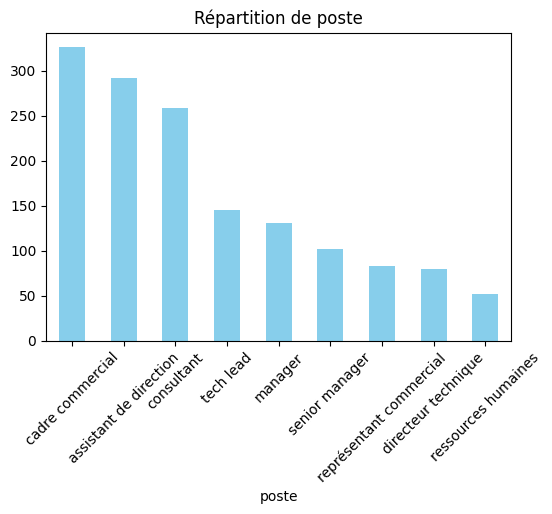

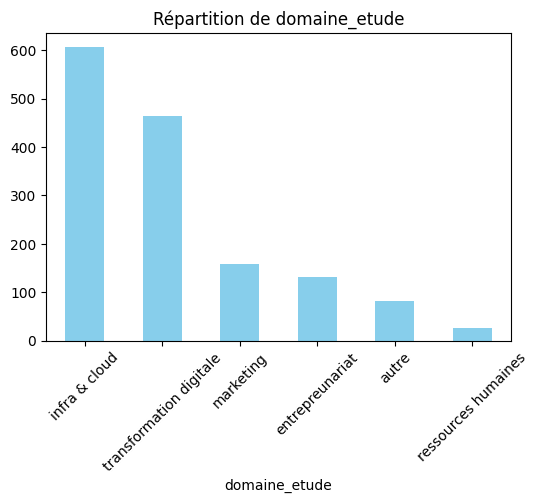

In [37]:
# faire un graphique avec barre pour poste, domaine d'étude
colonnes = ["poste", "domaine_etude"]

for col in colonnes:
    counts = df_merge[col].value_counts()  # compter les occurrences

    plt.figure(figsize=(6,4))  # nouvelle figure pour chaque variable
    counts.plot(kind="bar", color="skyblue")  # graphique en barres

    plt.title(f"Répartition de {col}")
    plt.xlabel(col)
    plt.ylabel("")
    plt.xticks(rotation=45)  # rotation pour mieux lire les labels
    plt.show()

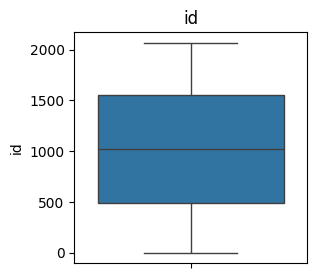

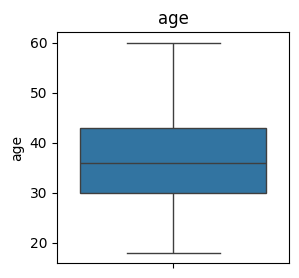

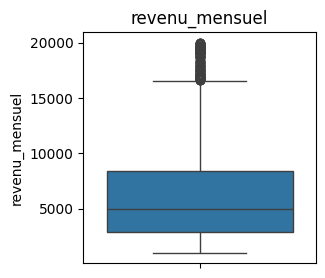

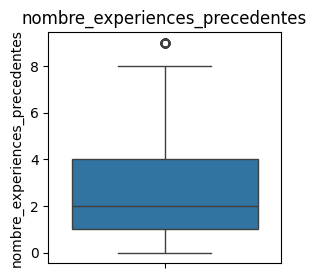

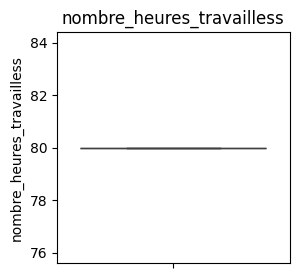

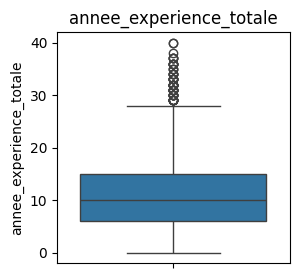

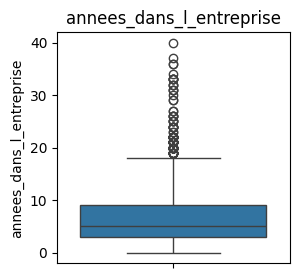

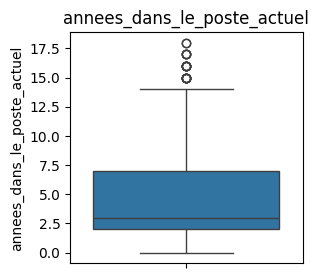

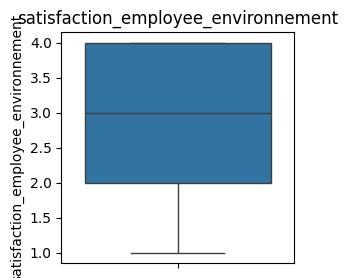

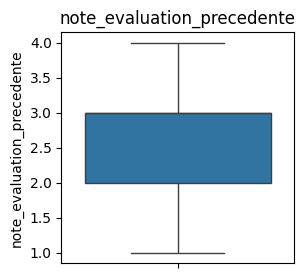

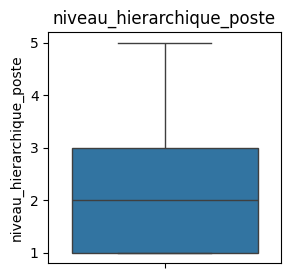

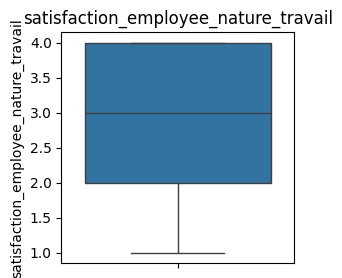

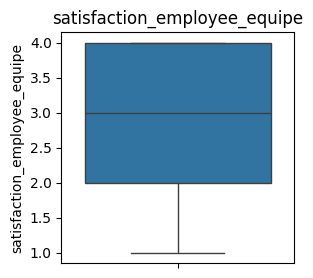

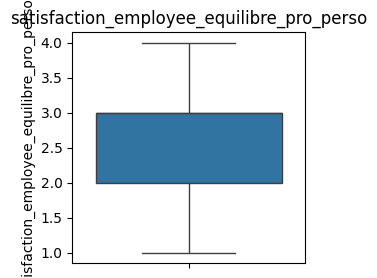

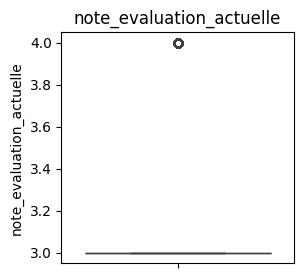

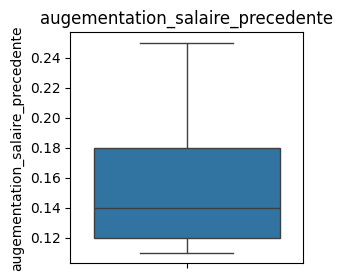

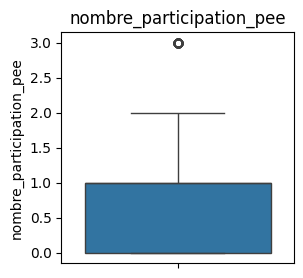

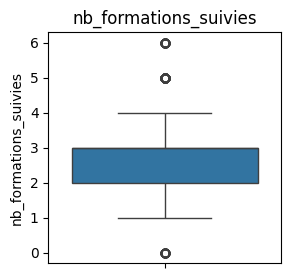

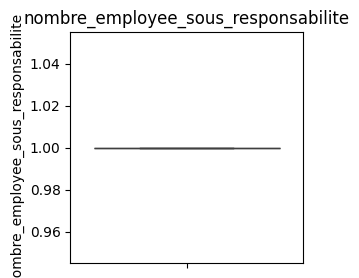

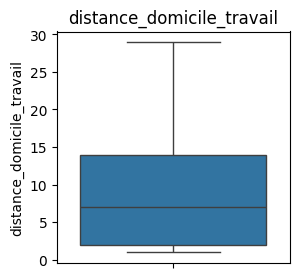

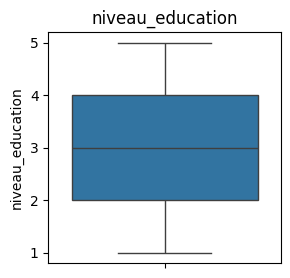

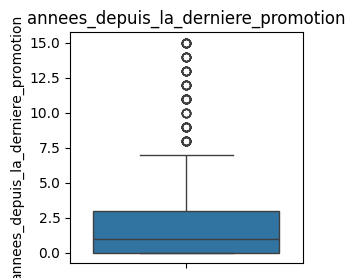

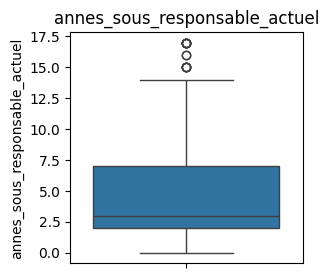

In [38]:
# Sélection des colonnes quantitatives
df_colonnes_quantitatives = df_merge.select_dtypes(include=["int64", "float"]).columns

# Boucle sur chaque colonne quantitative
for var in df_colonnes_quantitatives:
    plt.figure(figsize=(3,3))
    sns.boxplot(y=df_merge[var])
    plt.title(var)
    plt.show()

<Figure size 600x400 with 0 Axes>

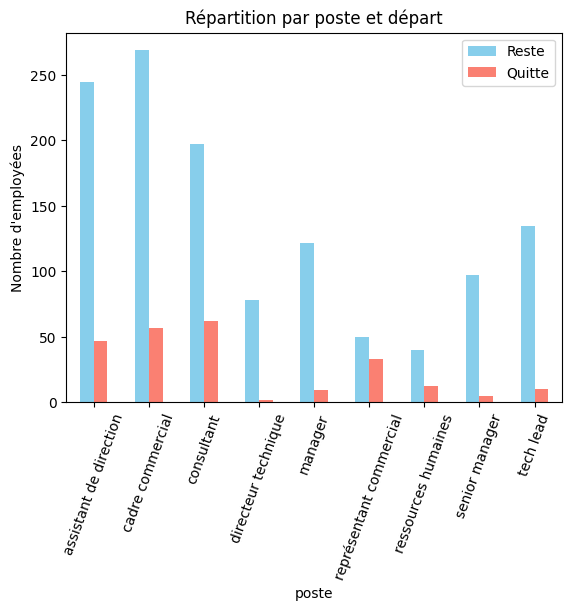

<Figure size 600x400 with 0 Axes>

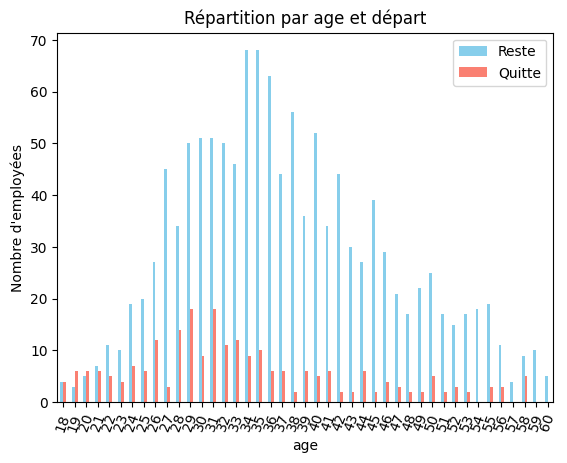

<Figure size 600x400 with 0 Axes>

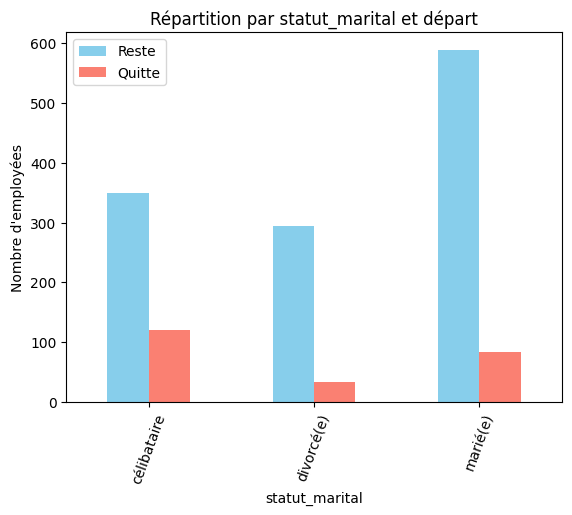

<Figure size 600x400 with 0 Axes>

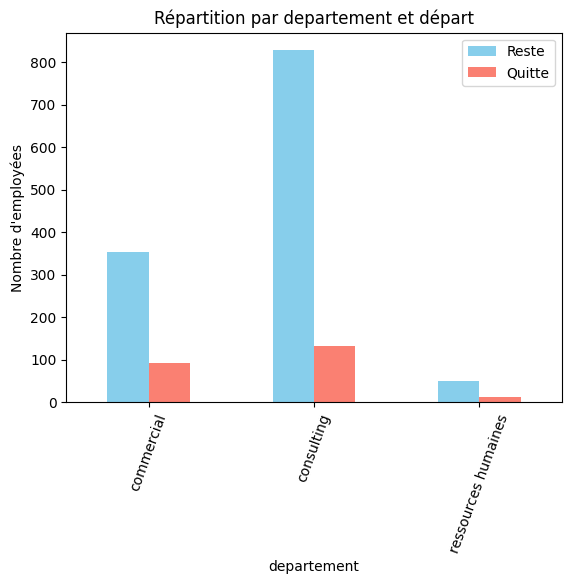

<Figure size 600x400 with 0 Axes>

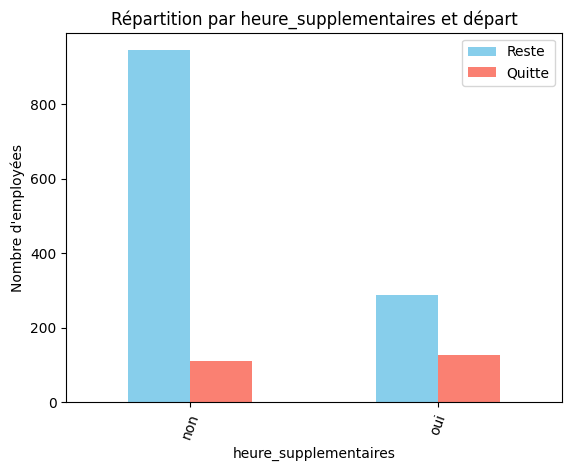

<Figure size 600x400 with 0 Axes>

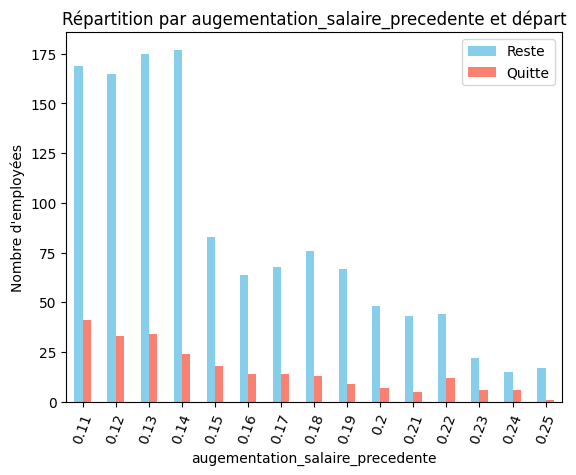

<Figure size 600x400 with 0 Axes>

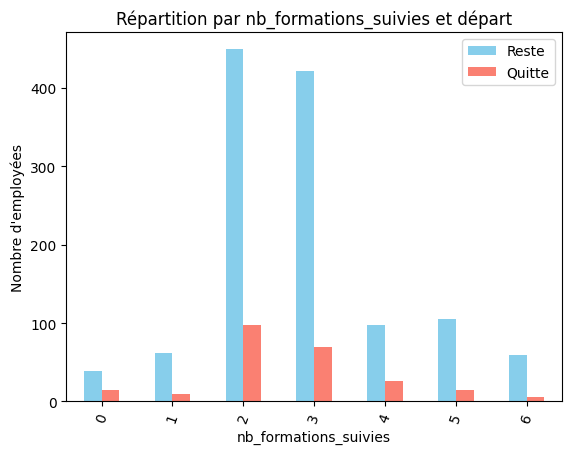

<Figure size 600x400 with 0 Axes>

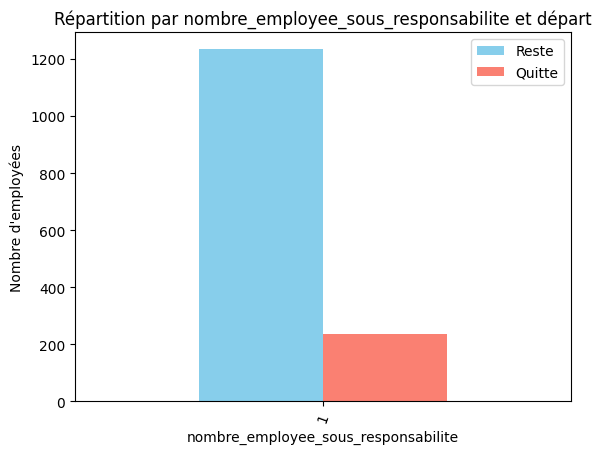

<Figure size 600x400 with 0 Axes>

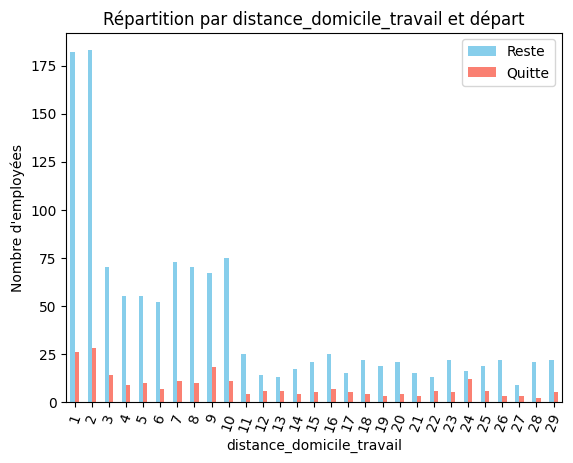

<Figure size 600x400 with 0 Axes>

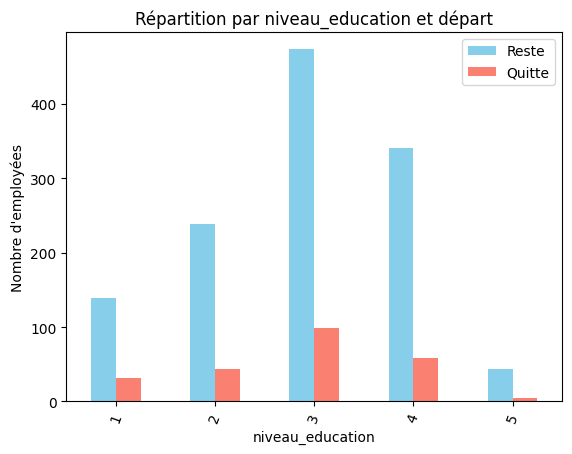

<Figure size 600x400 with 0 Axes>

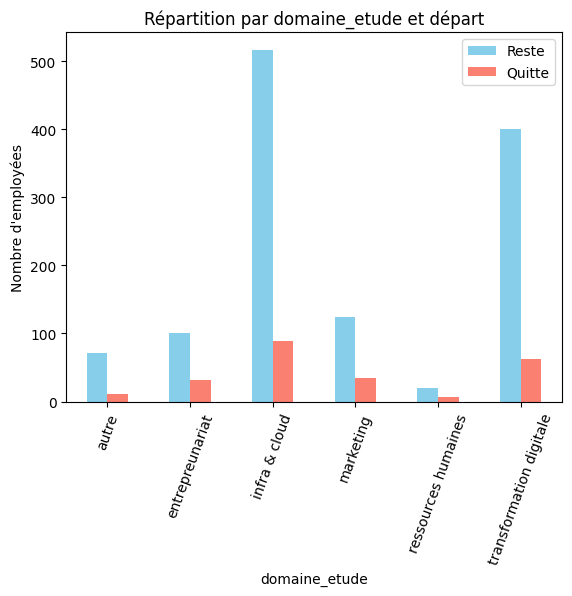

<Figure size 600x400 with 0 Axes>

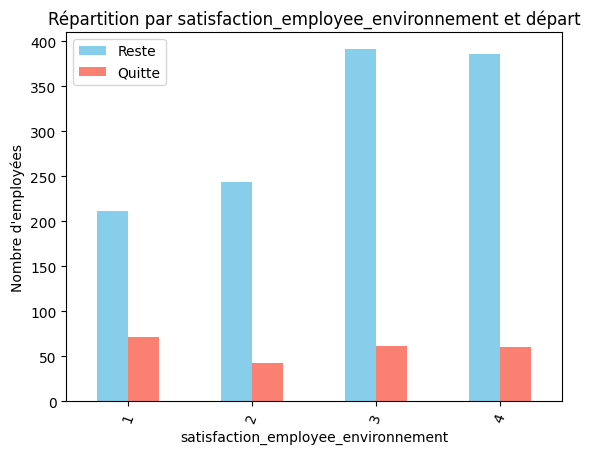

<Figure size 600x400 with 0 Axes>

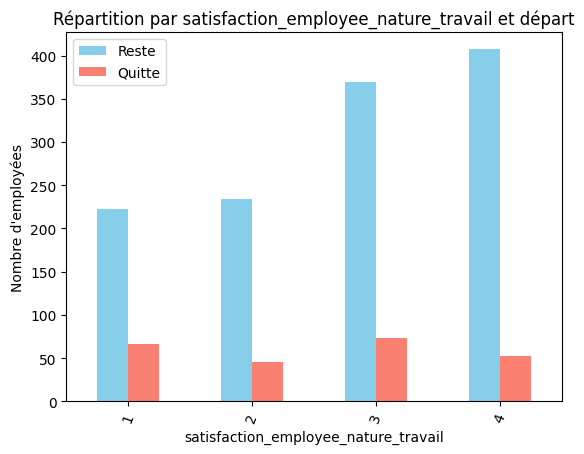

<Figure size 600x400 with 0 Axes>

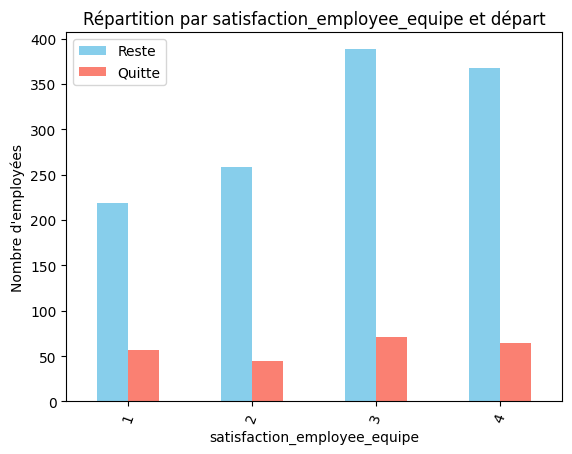

<Figure size 600x400 with 0 Axes>

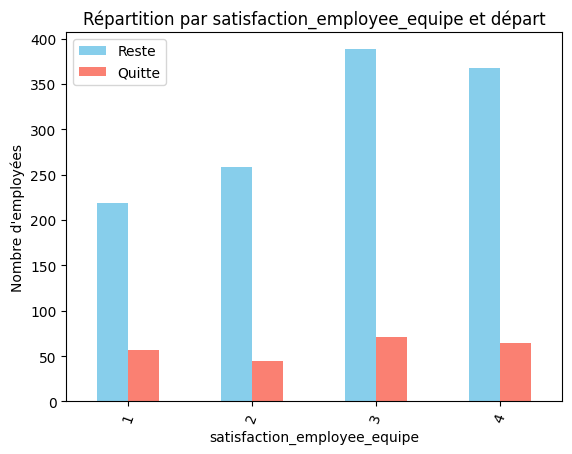

<Figure size 600x400 with 0 Axes>

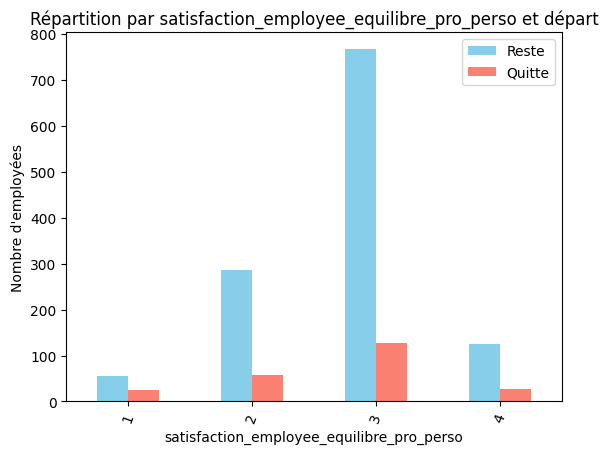

<Figure size 600x400 with 0 Axes>

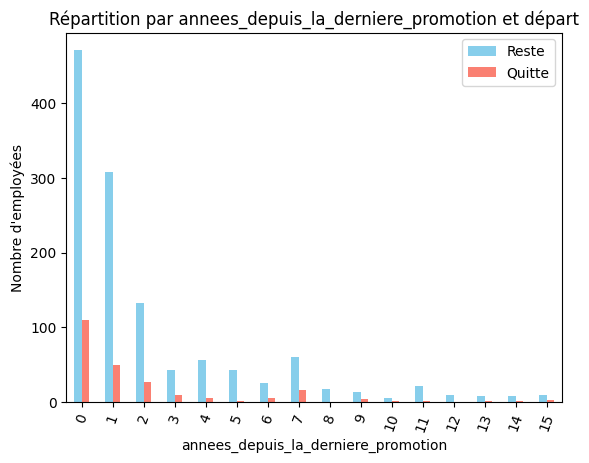

<Figure size 600x400 with 0 Axes>

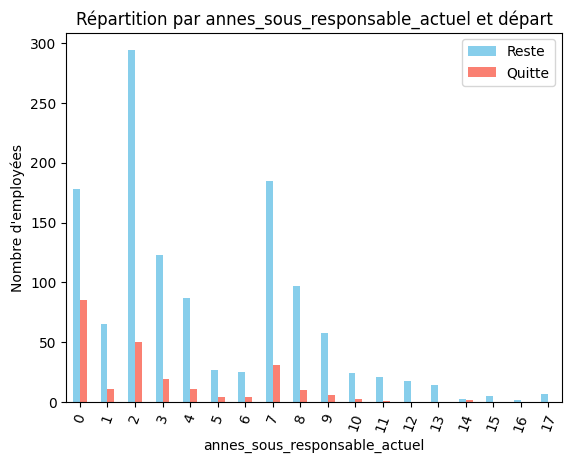

<Figure size 600x400 with 0 Axes>

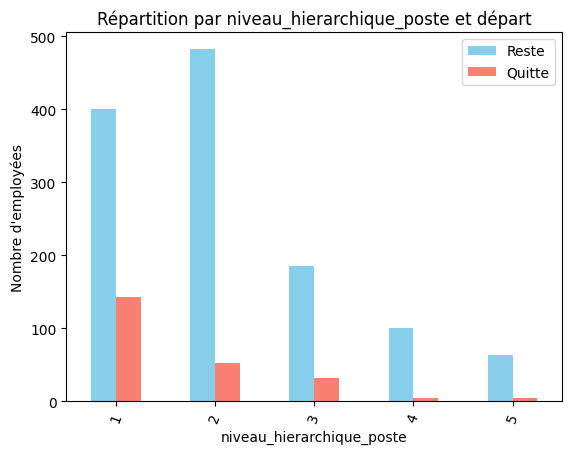

<Figure size 600x400 with 0 Axes>

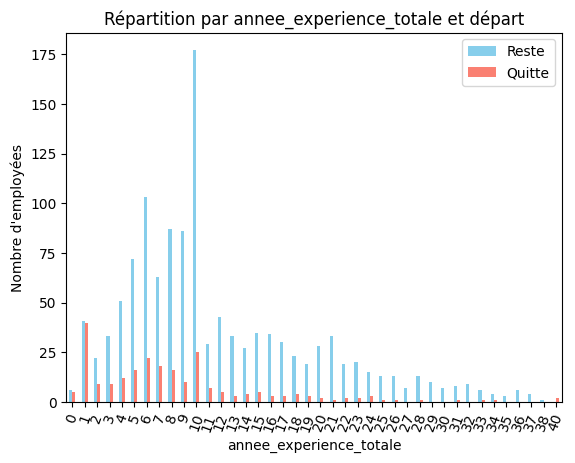

<Figure size 600x400 with 0 Axes>

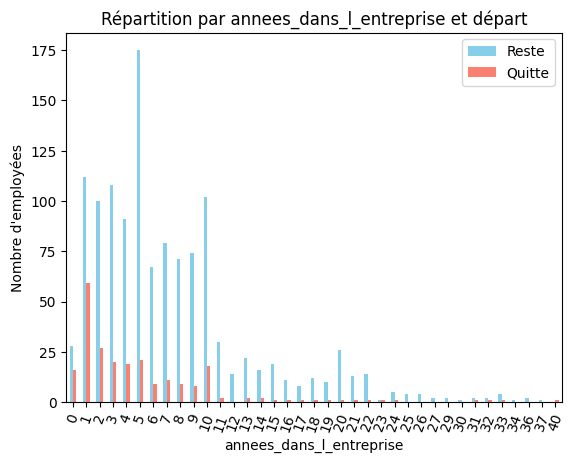

<Figure size 600x400 with 0 Axes>

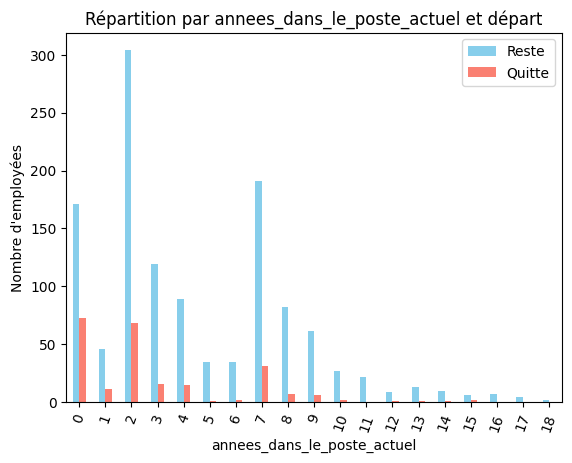

In [39]:
# Tableau croisé : nombre d'employées par poste et turnover
depart_categorie=["poste","age","statut_marital","departement", "heure_supplementaires", "augementation_salaire_precedente","nb_formations_suivies","nombre_employee_sous_responsabilite","distance_domicile_travail","niveau_education","domaine_etude","satisfaction_employee_environnement","satisfaction_employee_nature_travail", "satisfaction_employee_equipe","satisfaction_employee_equipe","satisfaction_employee_equilibre_pro_perso","annees_depuis_la_derniere_promotion","annes_sous_responsable_actuel","niveau_hierarchique_poste","annee_experience_totale","annees_dans_l_entreprise","annees_dans_le_poste_actuel"]

for cat in depart_categorie:
	table=pd.crosstab(df_merge[cat], df_merge["a_quitte_l_entreprise"])

	# Graphique en barres
	plt.figure(figsize=(6,4))
	table.plot(kind="bar", stacked=False, color=["skyblue","salmon"])
	plt.title(f"Répartition par {cat} et départ")
	plt.xlabel(cat)
	plt.ylabel("Nombre d'employées")
	plt.legend(["Reste", "Quitte"])
	plt.xticks(rotation=70)
	plt.show()